In [1]:
import geopandas as gpd

In [8]:
url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/albatross/elevation_prediction_cryosat2_SAR_A.parquet'

In [9]:
gdf = gpd.read_parquet(url)
gdf

,time,tidal_elevation_prediction_m,latitude,longitude,type,geometry
0,2019-04-03 00:42:11.249999872,-0.633424,-74.255775,-27.983294,cryosat2_SAR_A,POINT (-27.98329 -74.25578)
1,2019-04-03 00:42:11.249999872,-0.633644,-74.258522,-27.984816,cryosat2_SAR_A,POINT (-27.98482 -74.25852)
2,2019-04-03 00:42:11.249999872,-0.633204,-74.253021,-27.981771,cryosat2_SAR_A,POINT (-27.98177 -74.25302)
3,2019-04-03 00:42:11.249999872,-0.632985,-74.250275,-27.980249,cryosat2_SAR_A,POINT (-27.98025 -74.25027)
4,2019-04-03 00:42:11.249999872,-0.632766,-74.247520,-27.978729,cryosat2_SAR_A,POINT (-27.97873 -74.24752)
...,...,...,...,...,...,...
24947911,2019-10-12 03:30:56.249999872,NaN,-87.973984,67.921913,cryosat2_SAR_A,POINT (67.92191 -87.97398)
24947912,2019-10-12 03:30:56.249999872,NaN,-87.973816,68.000618,cryosat2_SAR_A,POINT (68.00062 -87.97382)
24947913,2019-10-12 03:30:56.249999872,NaN,-87.973648,68.079308,cryosat2_SAR_A,POINT (68.07931 -87.97365)
24947914,2019-10-12 03:30:56.249999872,NaN,-87.973480,68.157982,cryosat2_SAR_A,POINT (68.15798 -87.97348)


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [22]:
time_col = "time"
value_col = "tidal_elevation_prediction_m"

source_crs = "EPSG:4326"
target_crs = "EPSG:3031"

grid_size_m = 25_000  # 25 km
target_date = "2019-04-03"

In [23]:
# subset daily data
start = pd.Timestamp(target_date)
end = start + pd.Timedelta(days=7)

gdf_day = gdf.loc[
    (gdf[time_col] >= start) &
    (gdf[time_col] < end)
].copy()

gdf_day = gdf_day.dropna(subset=[value_col])

In [24]:
# reproject and regrid
gdf_3031 = gdf_day.to_crs(target_crs)

from shapely.geometry import box

minx, miny, maxx, maxy = gdf_3031.total_bounds

# Snap grid bounds to the 25 km grid
minx = np.floor(minx / grid_size_m) * grid_size_m
miny = np.floor(miny / grid_size_m) * grid_size_m
maxx = np.ceil(maxx / grid_size_m) * grid_size_m
maxy = np.ceil(maxy / grid_size_m) * grid_size_m

x_edges = np.arange(minx, maxx + grid_size_m, grid_size_m)
y_edges = np.arange(miny, maxy + grid_size_m, grid_size_m)

grid_cells = []

for x0 in x_edges[:-1]:
    for y0 in y_edges[:-1]:
        x1 = x0 + grid_size_m
        y1 = y0 + grid_size_m

        grid_cells.append(
            {
                "geometry": box(x0, y0, x1, y1),
                "grid_x": x0,
                "grid_y": y0
            }
        )

grid = gpd.GeoDataFrame(grid_cells, crs=target_crs)

print(len(grid))
grid.head()

54516


,geometry,grid_x,grid_y
0,"POLYGON ((-2675000 -2825000, -2675000 -2800000...",-2700000.0,-2825000.0
1,"POLYGON ((-2675000 -2800000, -2675000 -2775000...",-2700000.0,-2800000.0
2,"POLYGON ((-2675000 -2775000, -2675000 -2750000...",-2700000.0,-2775000.0
3,"POLYGON ((-2675000 -2750000, -2675000 -2725000...",-2700000.0,-2750000.0
4,"POLYGON ((-2675000 -2725000, -2675000 -2700000...",-2700000.0,-2725000.0


In [25]:
# assign pints to grid cells
points_in_grid = gpd.sjoin(
    gdf_3031,
    grid[["grid_x", "grid_y", "geometry"]],
    how="inner",
    predicate="within"
)

points_in_grid.head()

,time,tidal_elevation_prediction_m,latitude,longitude,type,geometry,index_right,grid_x,grid_y
0,2019-04-03 00:42:11.249999872,-0.633424,-74.255775,-27.983294,cryosat2_SAR_A,POINT (-807545.282 1519840.711),17873,-825000.0,1500000.0
1,2019-04-03 00:42:11.249999872,-0.633644,-74.258522,-27.984816,cryosat2_SAR_A,POINT (-807443.055 1519550.893),17873,-825000.0,1500000.0
2,2019-04-03 00:42:11.249999872,-0.633204,-74.253021,-27.981771,cryosat2_SAR_A,POINT (-807647.89 1520131.283),17873,-825000.0,1500000.0
3,2019-04-03 00:42:11.249999872,-0.632985,-74.250275,-27.980249,cryosat2_SAR_A,POINT (-807750.089 1520421.117),17873,-825000.0,1500000.0
4,2019-04-03 00:42:11.249999872,-0.632766,-74.247520,-27.978729,cryosat2_SAR_A,POINT (-807852.721 1520711.678),17873,-825000.0,1500000.0


In [26]:
grid_avg = (
    points_in_grid
    .groupby(["grid_x", "grid_y"], as_index=False)
    .agg(
        avg_tidal_elevation_m=(value_col, "mean"),
        n_observations=(value_col, "count"),
        first_time=(time_col, "min"),
        last_time=(time_col, "max")
    )
)

grid_avg.head()

,grid_x,grid_y,avg_tidal_elevation_m,n_observations,first_time,last_time
0,-2700000.0,1950000.0,-0.073892,69,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
1,-2675000.0,1925000.0,-0.074791,81,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
2,-2675000.0,1950000.0,-0.074230,8,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
3,-2675000.0,1975000.0,-0.359437,30,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000
4,-2675000.0,2000000.0,-0.357388,21,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000


In [27]:
grid_result = grid.merge(
    grid_avg,
    on=["grid_x", "grid_y"],
    how="left"
)

grid_result_nonnull = grid_result.dropna(subset=["avg_tidal_elevation_m"]).copy()

grid_result_nonnull.head()

,geometry,grid_x,grid_y,avg_tidal_elevation_m,n_observations,first_time,last_time
191,"POLYGON ((-2675000 1950000, -2675000 1975000, ...",-2700000.0,1950000.0,-0.073892,69.0,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
426,"POLYGON ((-2650000 1925000, -2650000 1950000, ...",-2675000.0,1925000.0,-0.074791,81.0,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
427,"POLYGON ((-2650000 1950000, -2650000 1975000, ...",-2675000.0,1950000.0,-0.074230,8.0,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
428,"POLYGON ((-2650000 1975000, -2650000 2000000, ...",-2675000.0,1975000.0,-0.359437,30.0,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000
429,"POLYGON ((-2650000 2000000, -2650000 2025000, ...",-2675000.0,2000000.0,-0.357388,21.0,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000


In [33]:
# use calving fronts as antarctica background
url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet'
gdf = gpd.read_parquet(url)
gdf['area'] = gdf.area
largest_polygon = gdf.sort_values('area', ascending=False).iloc[[0]]

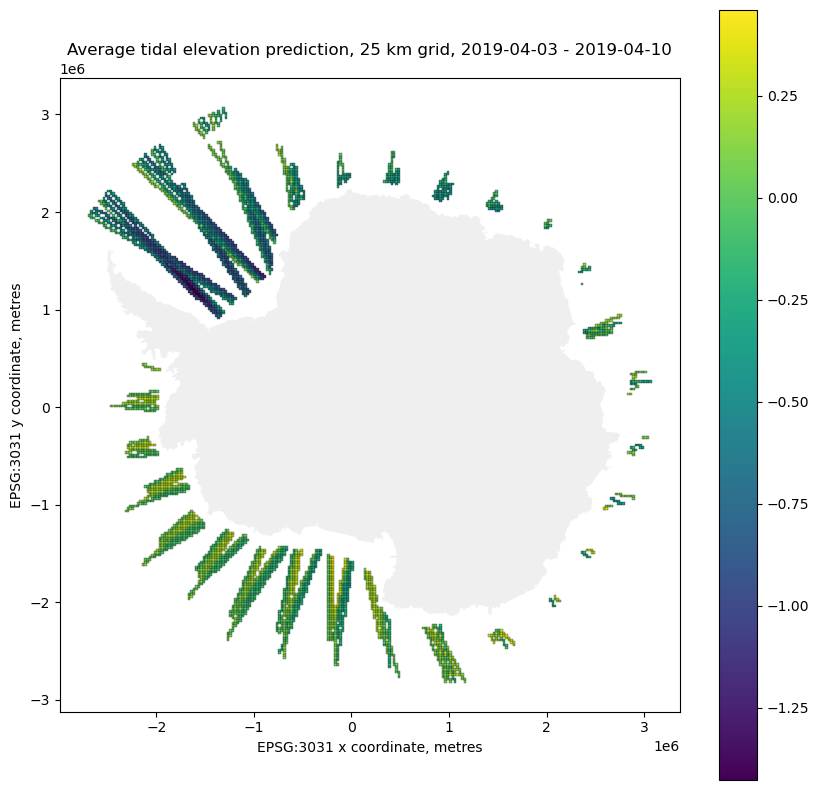

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

largest_polygon.plot(ax=ax, alpha=.12, color='grey')

grid_result_nonnull.plot(
    column="avg_tidal_elevation_m",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.2
)

ax.set_title(f"Average tidal elevation prediction, 25 km grid, {start.date()} - {end.date()}")
ax.set_xlabel("EPSG:3031 x coordinate, metres")
ax.set_ylabel("EPSG:3031 y coordinate, metres")
ax.set_aspect("equal")

plt.show()